# Deep Learning Fundamentals Project

This project has main objective to create a multi-layer perceptron to solve the Modified National Institute of Standards and Technology (MNIST) dataset classification problem. 

Notebook Structure: 
- Imports, seeding and GPU access verification
- Kaggle dataset download
- Initial dataset exploration
- Test, train, validation split
- Data processing
- Logging setup
- Baseline Softmax Model
- Baseline Multi Layer Perceptron Model
- Experiments
- Optuna hyperparameter tuning
- Results evaluation
- Evaluation on test data
- Saving best model
- Conclusion

Google Collab dependencies: 

In [1]:
# !pip install -q lightning torchmetrics torchvision \
# pandas numpy scikit-learn matplotlib seaborn tensorboard kaggle

Importing necessary libraries: 

In [2]:
import os
import lightning as L
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
import torch
from torch.utils.data import TensorDataset, DataLoader
import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import transforms
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
import optuna
from functools import partial
from torchinfo import summary 
from mnist import (
    AugmentedFlatDataset,
    seed_everything,
    pick_device,
    make_loaders_train_val,
    make_loaders_train_val_test,
    SoftmaxBaseline,
    MLP,
    run_experiment,
    make_ablation_grid,
    run_sweep,
    collect_misclassifications,
    show_grid,
    evaluate_model,
    report_and_cm,
    make_augmented_train_loader,
    objective_aug,
    LAYERS_CHOICES,
)

%matplotlib inline

Seeding for reproducability: 

In [3]:
SEED = 42
seed_everything(SEED)

Seed set to 42


Verifying versions: 

In [4]:
print(
    "Torch:",
    torch.__version__,
    "| Python:",
    platform.python_version(),
    "| Lightning:",
    L.__version__,
)

Torch: 2.8.0 | Python: 3.13.2 | Lightning: 2.5.5


Verifying GPU access: 

In [5]:
device = pick_device()
pin_mem = device.type == "cuda"
print("Using device:", device)

Using device: mps


# Downloading dataset from Kaggle: 

After kaggle.json file has been downloaded, on google collab: 
1) Congigure credentials
2) Move token
3) Set permissions
4) Make a directory for competition data
5) Download competition data into the new data directory 

In [6]:
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/&& chmod 600 ~/.kaggle/kaggle.json
# !mkdir -p data
# !kaggle competitions download -c digit-recognizer -p data
# !unzip -o data/digit-recognizer.zip -d data
# !ls -lah data

Locally via command line (same steps as above): 

In [7]:
# mkdir -p ~/.kaggle
# mv ~/Downloads/kaggle.json ~/.kaggle/
# chmod 600 ~/.kaggle/kaggle.json
# mkdir -p data
# kaggle competitions download -c digit-recognizer -p data
# unzip -o data/digit-recognizer.zip -d data
# ls -lh data

# Initial data exploration

Looking at the shape of the data: 

In [8]:
%cd /Users/bt/Documents/turing/deep_learning
print("cwd:", os.getcwd())

/Users/bt/Documents/turing/deep_learning
cwd: /Users/bt/Documents/turing/deep_learning


In [9]:
df = pd.read_csv("data/train.csv")
print("Data shape:", df.shape)

Data shape: (42000, 785)


In [10]:
df_test = pd.read_csv("data/test.csv")
print("Test data shape:", df_test.shape)

Test data shape: (28000, 784)


There are 42000 images in the training dataset, with 785 columns (flattened image, 28*28 grayscale image with label for each row.) The test data does not have labels.

Looking at data types: 

In [11]:
df.dtypes.groupby(df.dtypes).count()

int64    785
dtype: int64

Replace empty strings/whitespace to null values: 

In [12]:
df.select_dtypes("object").replace(r"^\s*$", np.nan, regex=True, inplace=True)

Any infinite values in the dataset? 

In [13]:
np.isinf(df.to_numpy()).any()

np.False_

No infinite values in the dataset.

Are there any null values in this dataset? 

In [14]:
print("nulls:", df.isna().sum().sum())

nulls: 0


No null values in this dataset. Are there any duplicated images? 

In [15]:
print("duplicates:", df.duplicated().sum())

duplicates: 0


No duplicate values are present in this dataset (including labels). What if the label is excluded? 

In [16]:
pix = df.drop(columns="label", errors="ignore")
print("duplicates:", pix.duplicated().sum())

duplicates: 0


No duplicate values are present in this dataset. 

Now, looking at numeric ranges: 
- Labels should be integers from 0-9, 
- Pixel range should be from 0-255.

In [17]:
invalid_mask = (pix < 0) | (pix > 255)
invalid_rows = invalid_mask.any(axis=1)
invalid_indices = df.index[invalid_rows]
print("Number of invalid rows:", invalid_rows.sum())
print("Indices of invalid rows:", list(invalid_indices))

Number of invalid rows: 0
Indices of invalid rows: []


In [18]:
print("Min pixel value:", pix.min().min())
print("Max pixel value:", pix.max().max())

Min pixel value: 0
Max pixel value: 255


In [19]:
print("Min label value:", df["label"].min())
print("Max label value:", df["label"].max())

Min label value: 0
Max label value: 9


All ranges are as expected. Are there any images that are all black? 

In [20]:
(pix.sum(axis=1) == 0).sum()

np.int64(0)

No images are all black. How about any images that are all white? 

In [21]:
pix.eq(255).all(axis=1).sum()

np.int64(0)

No images are all white. How about any outlier image rows? 

If an image is valid, the sum of all pixel values should be around the average value for all images in the dataset. Computing the total pixel intensity per image: 

In [22]:
row_sum = pix.sum(axis=1)

Now, computing z scores of those sums: 

In [23]:
z = zscore(row_sum)

It is possible to look at the distribution of total brightness per image: 

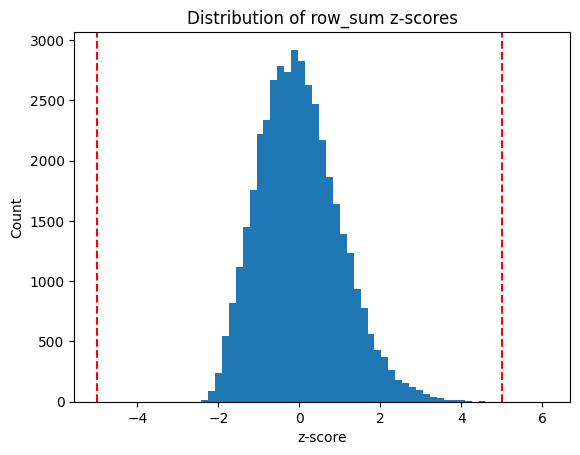

In [24]:
plt.hist(z, bins=50)
plt.axvline(5, color="r", linestyle="--")
plt.axvline(-5, color="r", linestyle="--")
plt.title("Distribution of row_sum z-scores")
plt.xlabel("z-score")
plt.ylabel("Count")
plt.show()

Here, each z value represents how many standard deviations an image's total pixel intensity is from the mean.

This looks like a normal distribution for image brightness.

Now, potential outlier rows will have an absolute z value over 5: 

In [25]:
outlier_mask = np.abs(z) > 5
outlier_indices = df.index[outlier_mask]
print("Number of outlier rows:", outlier_mask.sum())
print("Indices:", list(outlier_indices))

Number of outlier rows: 2
Indices: [1285, 8062]


Looking at these: 

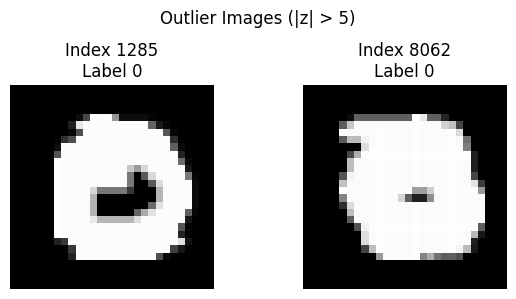

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, idx in zip(axes, outlier_indices):
    img = pix.loc[idx].to_numpy().reshape(28, 28)
    ax.imshow(img, cmap="gray")
    if "label" in df.columns:
        ax.set_title(f"Index {idx}\nLabel {df.loc[idx, 'label']}")
    else:
        ax.set_title(f"Index {idx}")
    ax.axis("off")

plt.suptitle("Outlier Images (|z| > 5)", fontsize=12)
plt.tight_layout()
plt.show()

These still do look like handwritten numbers, and will be kept. 

## Class distribution

Looking at class distribution: 


In [27]:
class_counts = df["label"].value_counts().sort_index()
class_counts

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64

Class distribution looks approximately even. Looking at this in terms of class ratios: 

In [28]:
class_ratios = 100 * (class_counts / len(df)).round(4)

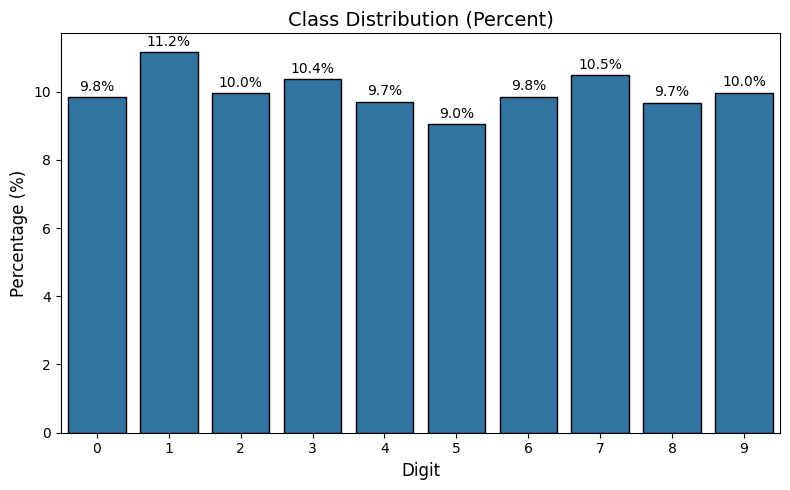

In [29]:
class_df = pd.DataFrame(
    {"Digit": class_ratios.index, "Percentage": class_ratios.values}
)
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=class_df, x="Digit", y="Percentage", edgecolor="black")

plt.title("Class Distribution (Percent)", fontsize=14)
plt.xlabel("Digit", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + 0.1,
        f"{p.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )
plt.tight_layout()
plt.show()

Classes generally seem to be evenly distributed, with 1 being the most popular class (11% of data). This means that a model's accuracy must be at least 11% in order to be meaningful. 

Before creating a model, it could be useful to examine some random digits to ensure that the data looks as expected: 

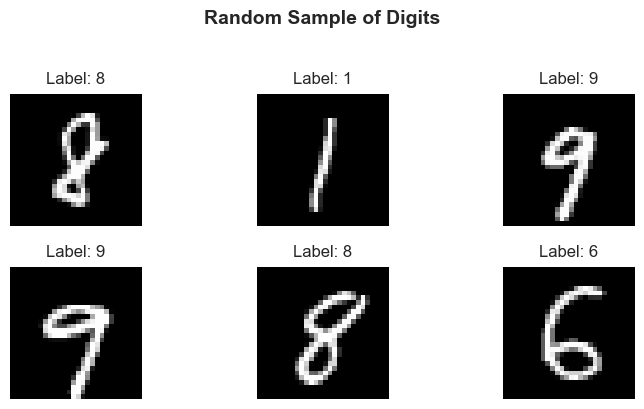

In [30]:
sns.set_theme(style="white")
sample_df = df.sample(6, random_state=42)

plt.figure(figsize=(8, 4))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img = row.drop("label").to_numpy().reshape(28, 28)
    label = int(row["label"])

    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Label: {label}", fontsize=12, pad=8)
    plt.axis("off")

plt.suptitle("Random Sample of Digits", fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

Observations: 
- Dataset is composed of handwritten digit images, flattened with 28*28 pixels per image, and is already clean. 

# Train, test, validation split

Now, x and y variables can be defined: 

In [31]:
X = df.drop(columns=["label"]).values
y = df["label"].values

Next, training, test, and validation data is split from the whole dataset: 

In [32]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [33]:
print("Shapes:")
print("train:", X_train.shape, y_train.shape)
print("val:", X_val.shape, y_val.shape)
print("test:", X_test.shape, y_test.shape)

Shapes:
train: (25200, 784) (25200,)
val: (8400, 784) (8400,)
test: (8400, 784) (8400,)


The training data has 25 200 examples, the validation and test data both have 8400 examples. Performing a quick check to ensure that class distribution has been preserved after splitting data: 

In [34]:
class_counts_train = df["label"].value_counts().sort_index()
class_ratios_train = 100 * (class_counts_train / len(df)).round(4)

class_counts_val = df["label"].value_counts().sort_index()
class_ratios_val = 100 * (class_counts_val / len(df)).round(4)

class_counts_test = df["label"].value_counts().sort_index()
class_ratios_test = 100 * (class_counts_test / len(df)).round(4)

class_ratios_df = pd.DataFrame(
    {
        "Digit": class_ratios_train.index,
        "Train (%)": class_ratios_train.values,
        "Validation (%)": class_ratios_val.values,
        "Test (%)": class_ratios_test.values,
    }
)
class_ratios_df

,Digit,Train (%),Validation (%),Test (%)
0,0,9.84,9.84,9.84
1,1,11.15,11.15,11.15
2,2,9.95,9.95,9.95
3,3,10.36,10.36,10.36
4,4,9.70,9.70,9.70
5,5,9.04,9.04,9.04
6,6,9.85,9.85,9.85
7,7,10.48,10.48,10.48
8,8,9.67,9.67,9.67
9,9,9.97,9.97,9.97


Class distribution has indeed been preserved across spliting data. 

# Data processing

The data is now normalized to [0, 1], as is common practice for deep learning problems. Some benefits to normalization of raw data include: 
- Raw pixel values (0-255) have a fairly large range and can be unevenly distributed. These large input magnitudes can induce the vanishing gradient problem during backpropagation. 
- Certain activation functions (sigmoid, tanh) work best when the input data is centered and has a small range. 
- Gradient descent can take equal sized steps when all features are on the same range (ex: between 0-1).
- Normalization ensures that all features are treated equally (no bright pixels dominate because of their scale alone). 

In addition, data types are changed to type float32 for x values and as int64 for labels to enable conversion to torch tensors: 

In [35]:
X_train_f = X_train.astype(np.float32) / 255.0
X_val_f = X_val.astype(np.float32) / 255.0
X_test_f = X_test.astype(np.float32) / 255.0

y_train_i = y_train.astype(np.int64)
y_val_i = y_val.astype(np.int64)
y_test_i = y_test.astype(np.int64)

Now, these are converted to torch tensors to use for modeling: 

In [36]:
Xtr = torch.from_numpy(X_train_f)
Xva = torch.from_numpy(X_val_f)
Xte = torch.from_numpy(X_test_f)

ytr = torch.from_numpy(y_train_i)
yva = torch.from_numpy(y_val_i)
yte = torch.from_numpy(y_test_i)

print(Xtr.shape, Xva.shape, Xte.shape, ytr.dtype, Xtr.dtype)

torch.Size([25200, 784]) torch.Size([8400, 784]) torch.Size([8400, 784]) torch.int64 torch.float32


Finally, a training, validation, and test TensorDatasets are defined along with the batch size. Pytorch DataLoaders are also defined to load data by batches, and batch shape and pixel range are verified: 

## Data loading

Now, data is loaded using Pytorch DataLoaders: 

In [37]:
batch_size = 128
num_workers = max(0, (os.cpu_count() or 1) - 1)

train_loader, val_loader, test_loader = make_loaders_train_val_test(
    Xtr, ytr, Xva, yva, Xte, yte, batch_size, num_workers, pin_mem
)

xb, yb = next(iter(train_loader))
print("batch shapes:", xb.shape, yb.shape, xb.dtype, yb.dtype)
print("pixel range:", float(xb.min()), float(xb.max()))

batch shapes: torch.Size([128, 784]) torch.Size([128]) torch.float32 torch.int64
pixel range: 0.0 1.0


Batch size, data type, and pixel ranges are all as expected. 

## Loading for augmented dataset

It is possible that making small torchvision transforms to the images in the training dataset will help the model to generalize better by learning slight invariances in the data, and so a loader for augmented (slightly transformed) images is also set up: 

In [60]:
aug = transforms.Compose(
    [
        transforms.RandomAffine(
            degrees=10, translate=(0.05, 0.05), shear=5, scale=(0.95, 1.05)
        ),
    ]
)

train_aug_loader = make_augmented_train_loader(
    Xtr, ytr, transform=aug, batch_size=batch_size, num_workers=0, seed=42
)

A quick visualization of the original and augmented data gives: 

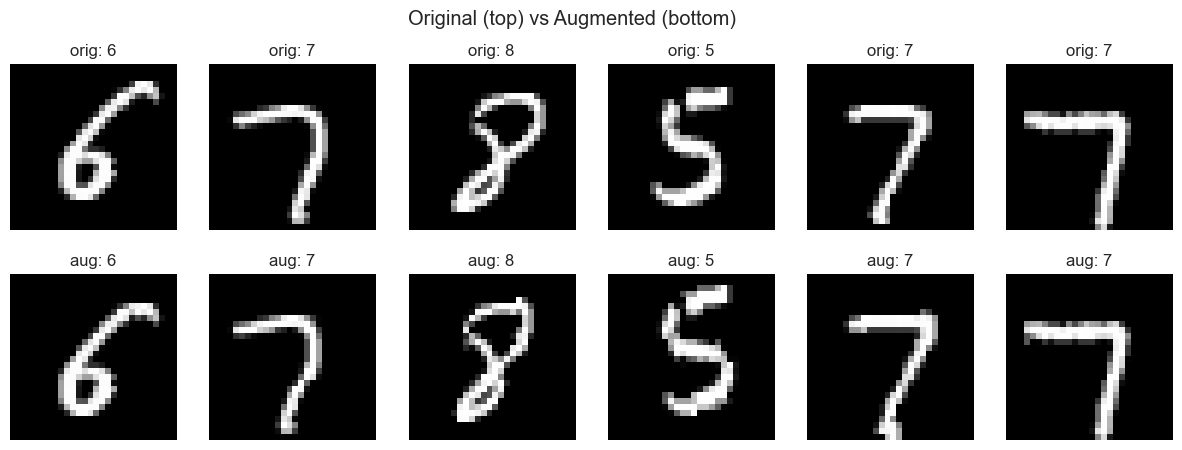

In [ ]:
torch.manual_seed(42)
idxs = torch.randint(0, Xtr.shape[0], (12,))
orig = Xtr[idxs].view(-1, 28, 28).cpu()
labels = ytr[idxs].cpu()

aug_subset = AugmentedFlatDataset(Xtr[idxs], ytr[idxs], transform=aug)
aug_loader = DataLoader(aug_subset, batch_size=len(idxs), shuffle=False, num_workers=0)
xb_aug, yb_aug = next(iter(aug_loader))
aug_imgs = xb_aug.view(-1, 28, 28).cpu()

cols = 6
rows = 2
plt.figure(figsize=(2.5*cols, 2.5*rows))
for i in range(min(len(idxs), cols)):
    plt.subplot(rows, cols, i+1)
    plt.imshow(orig[i], cmap="gray")
    plt.title(f"orig: {labels[i].item()}")
    plt.axis("off")
    plt.subplot(rows, cols, cols + i + 1)
    plt.imshow(aug_imgs[i], cmap="gray")
    plt.title(f"aug: {yb_aug[i].item()}")
    plt.axis("off")
plt.suptitle("Original (top) vs Augmented (bottom)")
plt.show()


The augmented training data does not seem to have lost any information.

# Logging setup: 

Tensorboard is used for logging here to keep track of experiments : 

In [40]:
logger = TensorBoardLogger("experiments", name="baseline")
print("TensorBoard log dir:", logger.log_dir)
# In terminal, run: tensorboard --logdir experiments

TensorBoard log dir: experiments/baseline/version_0


# Baseline Softmax Model

Softmax regression is now used as a baseline model. The metric chosen for this dataset evaluation is **accuracy**, as the dataset is balanced.  

This: 
- builds a single linear layer that maps the 784 features to 10 class logits,
- uses cross entropy loss
- logs loss and accuracy for training and validation data each epoch
- optimizes with Adam 

Callbacks are first configured: 
- ckpt for validation accuracy,
- early stopping if model performance does not improve over three runs

Then, a PyTorch Lightning trainer is created. 

In [41]:
ckpt = ModelCheckpoint(
    monitor="val_acc", mode="max", save_top_k=1, filename="{epoch}-{val_acc:.4f}"
)
early = EarlyStopping(monitor="val_acc", mode="max", patience=3)

trainer = L.Trainer(
    max_epochs=10,
    accelerator="gpu",
    devices=1,
    logger=logger,
    callbacks=[ckpt, early],
    log_every_n_steps=10,
    deterministic=True,
)

print("Logger dir:", logger.save_dir, "Run name:", logger.name)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Logger dir: experiments Run name: baseline


Now, the baseline model is trained: 

In [42]:
model = SoftmaxBaseline(lr=1e-3)
trainer.fit(model, train_loader, val_loader)

print("Best ckpt:", ckpt.best_model_path)
if ckpt.best_model_score is not None:
    print("Best val_acc:", float(ckpt.best_model_score))


  | Name  | Type   | Params | Mode 
-----------------------------------------
0 | layer | Linear | 7.9 K  | train
-----------------------------------------
7.9 K     Trainable params
0         Non-trainable params
7.9 K     Total params
0.031     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Best ckpt: experiments/baseline/version_0/checkpoints/epoch=8-val_acc=0.9173.ckpt
Best val_acc: 0.9172618985176086


After 10 training epochs, an initial validation accuracy of about 91% is found.

# Baseline Multi Layer Perceptron Model

Now that a baseline accuracy has been found, a MLP model can be trained to the data: 

Baseline parameters are defined: 

In [43]:
baseline = dict(
    optimizer="adam",
    batch_size=128,
    activation="relu",
    lr=1e-3,
    dropout=0.3,
    hidden_layers=(512, 256),
    loss="ce",
    weight_decay=0.0,
    max_epochs=10,
)

logger_mlp = TensorBoardLogger("experiments", name="mlp")

Now, the baseline experiment is run (no scheduler): 

In [44]:
res = run_experiment(
    "baseline_mlp",
    Xtr=Xtr,
    ytr=ytr,
    Xva=Xva,
    yva=yva,
    layers=(512, 256),
    dropout=0.3,
    lr=1e-3,
    opt="adam",
    batch_size=128,
    max_epochs=10,
    use_bn=True,
    activation="relu",
    loss="ce",
    weight_decay=0.0,
    save_checkpoints=True,
    monitor="val_acc",
    patience=3,
    log_dir="experiments",
    scheduler=None,
)

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name | Type       | Params | Mode 
--------------------------------------------
0 | net  | Sequential | 537 K  | train
--------------------------------------------
537 K     Trainable params
0         Non-trainable params
537 K     Total params
2.149     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode



=== baseline_mlp ===


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Best ckpt: experiments/baseline_mlp/version_0/checkpoints/epoch-epoch=0008-val_acc=val_acc=0.9750.ckpt
Best metric: 0.9750000238418579


Validation accuracy has now increased to 97.5%. Running the same experiment with a cosine scheduler: 

In [45]:
res = run_experiment(
    "baseline_mlp",
    Xtr=Xtr,
    ytr=ytr,
    Xva=Xva,
    yva=yva,
    layers=(512, 256),
    dropout=0.3,
    lr=1e-3,
    opt="adam",
    batch_size=128,
    max_epochs=10,
    use_bn=True,
    activation="relu",
    loss="ce",
    weight_decay=0.0,
    save_checkpoints=True,
    monitor="val_acc",
    patience=3,
    log_dir="experiments",
)

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name | Type       | Params | Mode 
--------------------------------------------
0 | net  | Sequential | 537 K  | train
--------------------------------------------
537 K     Trainable params
0         Non-trainable params
537 K     Total params
2.149     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode



=== baseline_mlp ===


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Best ckpt: experiments/baseline_mlp/version_1/checkpoints/epoch-epoch=0008-val_acc=val_acc=0.9761.ckpt
Best metric: 0.9760714173316956


Using the cosine scheduler for learning rate minimally increases validation accuracy (by 0.1%). This will be used for the rest of the project. 

The augmented dataset will now be compared with the same baseline and initial parameters with the augmented training data: 

Looking at the architecture for the untrained baseline model: 

In [46]:
model = MLP(layers=(512, 256), dropout=0.3, lr=1e-3, opt="adam", use_bn=True, activation="relu", loss="ce", weight_decay=0.0)
summary(model, input_size=(1, 784))

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Linear: 2-1                       [1, 512]                  401,920
│    └─BatchNorm1d: 2-2                  [1, 512]                  1,024
│    └─ReLU: 2-3                         [1, 512]                  --
│    └─Dropout: 2-4                      [1, 512]                  --
│    └─Linear: 2-5                       [1, 256]                  131,328
│    └─BatchNorm1d: 2-6                  [1, 256]                  512
│    └─ReLU: 2-7                         [1, 256]                  --
│    └─Dropout: 2-8                      [1, 256]                  --
│    └─Linear: 2-9                       [1, 10]                   2,570
Total params: 537,354
Trainable params: 537,354
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.54
Input size (MB): 0.00
Forw

Here, the MLP model architecture is examined with baseline parameters: 
- There are 3 linear layers with batchnorm1d to normalize activations and stabilize training, 
    - ReLU activation function is used to introduce non-linearity. 
    - Dropout is used to randomly drop training activations and add some regularization. 

## Augmented dataset baseline: 

In [47]:
res_aug = run_experiment(
    "baseline_mlp_aug",
    Xtr=Xtr,
    ytr=ytr,
    Xva=Xva,
    yva=yva,
    layers=(512, 256),
    dropout=0.3,
    lr=1e-3,
    opt="adam",
    batch_size=128,
    max_epochs=10,
    patience=3,
    num_workers=0,
    log_tensorboard=True,
    save_checkpoints=True,
    train_loader_override=train_aug_loader,
)

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name | Type       | Params | Mode 
--------------------------------------------
0 | net  | Sequential | 537 K  | train
--------------------------------------------
537 K     Trainable params
0         Non-trainable params
537 K     Total params
2.149     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode



=== baseline_mlp_aug ===


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/bt/Documents/turing/deep_learning/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/bt/Documents/turing/deep_learning/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Best ckpt: experiments/baseline_mlp_aug/version_0/checkpoints/epoch-epoch=0009-val_acc=val_acc=0.9821.ckpt
Best metric: 0.9821428656578064


The validation dataset found with the augmented training data (98.2%) is higher than that found with no augmentation: 

In [48]:
print(
    "Non augmented validation accuracy: ",
    res["val_acc"],
    "Augmented validation accuracy: ",
    res_aug["val_acc"],
)

Non augmented validation accuracy:  0.9748809337615967 Augmented validation accuracy:  0.9821428656578064


The augmented dataset has better validation accuracy, and will be used from here. 

## Looking at misclassified examples

Before moving on, it could be useful to see the model's most frequent wrong predictions. 

First, the validation data is loaded: 

In [49]:
num_workers = 0
_, val_loader = make_loaders_train_val(
    Xtr, ytr, Xva, yva, batch_size=128, num_workers=num_workers
)

Now, the baseline model is loaded from the checkpoint, and wrong predictions are collected: 

In [50]:
model_aug = MLP.load_from_checkpoint(res_aug["best_ckpt"]).eval()
device = (
    "cuda"
    if torch.cuda.is_available()
    else (
        "mps"
        if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
        else "cpu"
    )
)

Total misclassified (val): 150


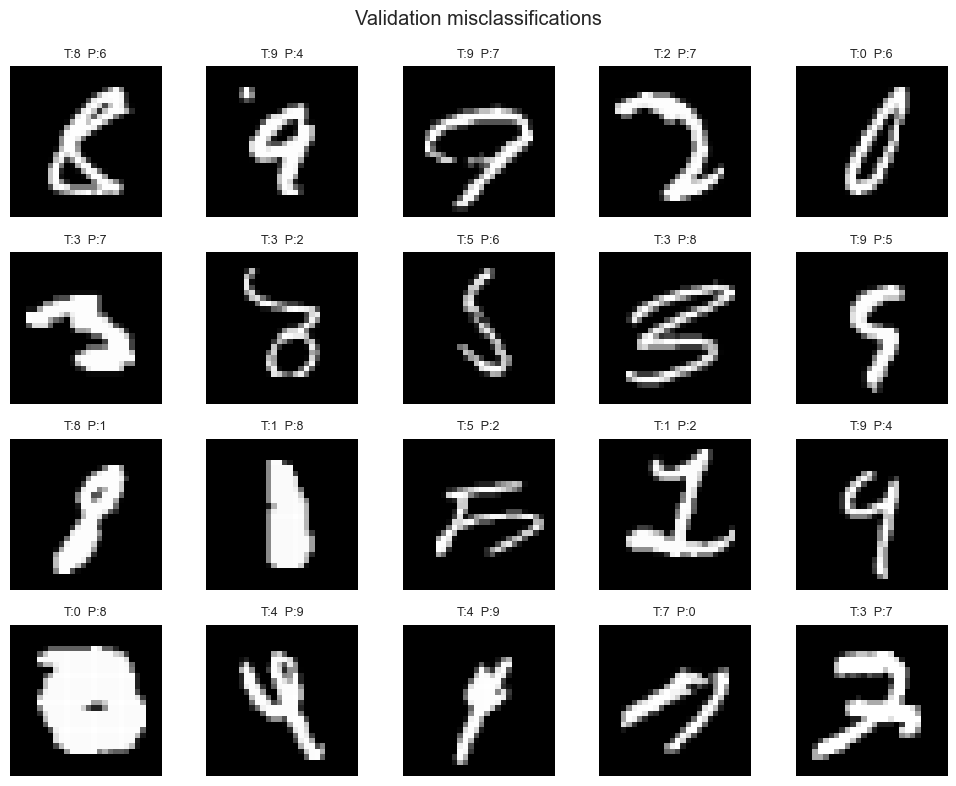

Top mispairs (count):


true  pred
9     7       13
3     2       11
9     4        7
3     7        7
      5        7
2     7        6
8     9        5
7     2        5
3     8        5
0     6        4
Name: count, dtype: int64

In [51]:
wrong_imgs, wrong_true, wrong_pred, wrong_conf = collect_misclassifications(
    model_aug, val_loader, device=device
)
print("Total misclassified (val):", len(wrong_imgs))
show_grid(
    wrong_imgs,
    wrong_true,
    wrong_pred,
    n=20,
    cols=5,
    title="Validation misclassifications",
)

df_err = pd.DataFrame({"true": wrong_true.numpy(), "pred": wrong_pred.numpy()})
print("Top mispairs (count):")
display(df_err.value_counts().head(10))

Some of these predictions are hard for a human to see, but some are simply wrongly identified. Looking at the top mispairs (9 predicted as 7): 

Showing up to 36 samples for 9->7, found: 13


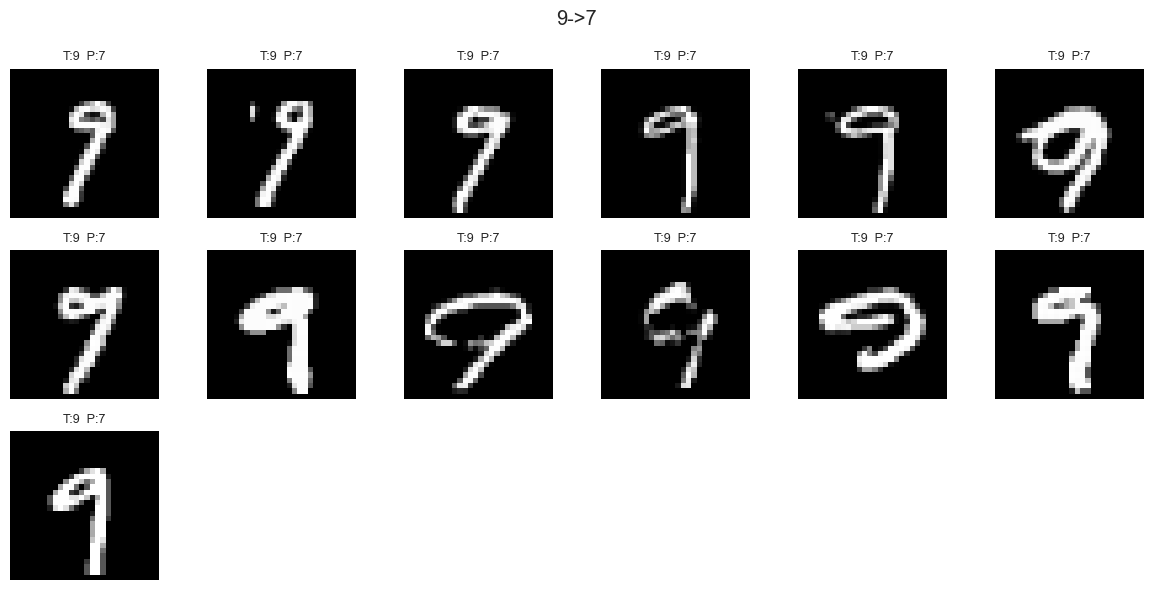

In [52]:
true_c, pred_c = 9, 7
mask = (wrong_true == true_c) & (wrong_pred == pred_c)
idx_sel = torch.where(mask)[0]
print(f"Showing up to 36 samples for {true_c}->{pred_c}, found:", len(idx_sel))
show_grid(
    wrong_imgs,
    wrong_true,
    wrong_pred,
    idx_sel=idx_sel,
    n=36,
    cols=6,
    title=f"{true_c}->{pred_c}",
)

The model has the most trouble mixing up 9 as 7 or 3 as 2. Now, different model parameters are changed one by one to try to minimize model misclassifications: 

# Experiments: 

Now, experiments are run while changing one model parameter at a time while keeping others constant to see each parameter's contribution to validation accuracy.

## Optimizer 

First, stochastic gradient descent (sgd), adam (adaptive moment estimation), and adamw (decoupled weight decay) optimizers are tested with the MLP model on the data: 

In [53]:
out_dir = "experiments/summaries"
os.makedirs(out_dir, exist_ok=True)

In [54]:
opt_grid = make_ablation_grid(baseline, optimizers=["sgd", "adam", "adamw"])
df_opt, best_opt = run_sweep(
    "abl_opt_aug",
    opt_grid,
    Xtr=Xtr,
    ytr=ytr,
    Xva=Xva,
    yva=yva,
    tb_logging=True,
    save_ckpt_each=False,
    train_loader_override=train_aug_loader,
)
df_opt = df_opt.sort_values("val_acc", ascending=False).reset_index(drop=True)
display(df_opt.head(10))
df_opt.to_csv(f"{out_dir}/abl_optimizer_aug.csv", index=False)
df_opt.to_json(f"{out_dir}/abl_optimizer_aug.json", orient="records", indent=2)

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name | Type       | Params | Mode 
--------------------------------------------
0 | net  | Sequential | 537 K  | train
--------------------------------------------
537 K     Trainable params
0         Non-trainable params
537 K     Total params
2.149     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode



=== abl_opt_aug_exp_001 ===


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/bt/Documents/turing/deep_learning/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Best ckpt: (not saved)
Best metric: 0.9819047451019287


,name,val_acc,val_loss,p_optimizer,p_batch_size,p_activation,p_lr,p_dropout,p_hidden_layers,p_loss,p_weight_decay,p_max_epochs
0,abl_opt_aug_exp_003,0.981905,0.059159,adamw,128,relu,0.001,0.3,"(512, 256)",ce,0.0,10
1,abl_opt_aug_exp_002,0.979167,0.065853,adam,128,relu,0.001,0.3,"(512, 256)",ce,0.0,10
2,abl_opt_aug_exp_001,0.949286,0.174174,sgd,128,relu,0.001,0.3,"(512, 256)",ce,0.0,10


With all other default parameters constant, the adamw has the best performance (98.2% validation accuracy). It is possible that stochastic gradient descent has the worst performance due to an non optimized learning rate. 

## Activation: 

Testing out 5 activation functions (ReLU (Rectified Linear Unit), GELU (Gaussian Error Linear Unit), Leaky ReLU, tanh (Hyperbolic Tangent), and ELU (Exponential Linear Unit)) gives: 

In [55]:
act_grid = make_ablation_grid(
    baseline, activations=["relu", "gelu", "leaky", "tanh", "elu"]
)
df_act, best_act = run_sweep(
    "abl_act_aug",
    act_grid,
    Xtr=Xtr,
    ytr=ytr,
    Xva=Xva,
    yva=yva,
    tb_logging=True,
    save_ckpt_each=False,
    train_loader_override=train_aug_loader,
)
df_act = df_act.sort_values("val_acc", ascending=False).reset_index(drop=True)
display(df_act.head(10))
df_act.to_csv(f"{out_dir}/abl_activation_aug.csv", index=False)
df_act.to_json(f"{out_dir}/abl_activation_aug.json", orient="records", indent=2)

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name | Type       | Params | Mode 
--------------------------------------------
0 | net  | Sequential | 537 K  | train
--------------------------------------------
537 K     Trainable params
0         Non-trainable params
537 K     Total params
2.149     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode



=== abl_act_aug_exp_001 ===


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/bt/Documents/turing/deep_learning/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Best ckpt: (not saved)
Best metric: 0.9741666913032532


,name,val_acc,val_loss,p_optimizer,p_batch_size,p_activation,p_lr,p_dropout,p_hidden_layers,p_loss,p_weight_decay,p_max_epochs
0,abl_act_aug_exp_003,0.982262,0.059071,adam,128,leaky,0.001,0.3,"(512, 256)",ce,0.0,10
1,abl_act_aug_exp_001,0.982024,0.059634,adam,128,relu,0.001,0.3,"(512, 256)",ce,0.0,10
2,abl_act_aug_exp_002,0.981667,0.058304,adam,128,gelu,0.001,0.3,"(512, 256)",ce,0.0,10
3,abl_act_aug_exp_005,0.974167,0.088234,adam,128,elu,0.001,0.3,"(512, 256)",ce,0.0,10
4,abl_act_aug_exp_004,0.970357,0.091636,adam,128,tanh,0.001,0.3,"(512, 256)",ce,0.0,10


The Leaky ReLU activation function returns the highest validation accuracy with all other parameters being kept the same as the baseline, though it gives essentially the same validation accuracy as the non-leaky ReLU activation function. 

## Learning rate

Now, testing out a few learning rates between 3e-2 and 3e-4: 

In [56]:
lr_grid = make_ablation_grid(baseline, lrs=[3e-4, 1e-3, 3e-3, 1e-2, 3e-2])
df_lr, best_lr = run_sweep(
    "abl_lr_aug",
    lr_grid,
    Xtr=Xtr,
    ytr=ytr,
    Xva=Xva,
    yva=yva,
    tb_logging=True,
    save_ckpt_each=False,
    train_loader_override=train_aug_loader,
)
df_lr = df_lr.sort_values("val_acc", ascending=False).reset_index(drop=True)
display(df_lr.head(10))

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name | Type       | Params | Mode 
--------------------------------------------
0 | net  | Sequential | 537 K  | train
--------------------------------------------
537 K     Trainable params
0         Non-trainable params
537 K     Total params
2.149     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode



=== abl_lr_aug_exp_001 ===


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/bt/Documents/turing/deep_learning/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Best ckpt: (not saved)
Best metric: 0.9752380847930908


,name,val_acc,val_loss,p_optimizer,p_batch_size,p_activation,p_lr,p_dropout,p_hidden_layers,p_loss,p_weight_decay,p_max_epochs
0,abl_lr_aug_exp_003,0.983691,0.052884,adam,128,relu,0.0030,0.3,"(512, 256)",ce,0.0,10
1,abl_lr_aug_exp_004,0.981667,0.057035,adam,128,relu,0.0100,0.3,"(512, 256)",ce,0.0,10
2,abl_lr_aug_exp_002,0.981429,0.060143,adam,128,relu,0.0010,0.3,"(512, 256)",ce,0.0,10
3,abl_lr_aug_exp_001,0.978929,0.071955,adam,128,relu,0.0003,0.3,"(512, 256)",ce,0.0,10
4,abl_lr_aug_exp_005,0.975238,0.074807,adam,128,relu,0.0300,0.3,"(512, 256)",ce,0.0,10


The learning rate that gives the highest validation accuracy was 0.003.

## Dropout

Now, varying the dropout parameter gives: 

In [57]:
do_grid = make_ablation_grid(baseline, dropouts=[0, 0.1, 0.2, 0.3, 0.5])
df_do, best_do = run_sweep(
    "abl_dropout_aug",
    do_grid,
    Xtr=Xtr,
    ytr=ytr,
    Xva=Xva,
    yva=yva,
    tb_logging=True,
    save_ckpt_each=False,
    train_loader_override=train_aug_loader,
)
df_do = df_do.sort_values("val_acc", ascending=False).reset_index(drop=True)
display(df_do.head(10))

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name | Type       | Params | Mode 
--------------------------------------------
0 | net  | Sequential | 537 K  | train
--------------------------------------------
537 K     Trainable params
0         Non-trainable params
537 K     Total params
2.149     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode



=== abl_dropout_aug_exp_001 ===


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/bt/Documents/turing/deep_learning/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Best ckpt: (not saved)
Best metric: 0.977142870426178


,name,val_acc,val_loss,p_optimizer,p_batch_size,p_activation,p_lr,p_dropout,p_hidden_layers,p_loss,p_weight_decay,p_max_epochs
0,abl_dropout_aug_exp_002,0.981786,0.055569,adam,128,relu,0.001,0.1,"(512, 256)",ce,0.0,10
1,abl_dropout_aug_exp_001,0.981310,0.057331,adam,128,relu,0.001,0.0,"(512, 256)",ce,0.0,10
2,abl_dropout_aug_exp_003,0.981191,0.059501,adam,128,relu,0.001,0.2,"(512, 256)",ce,0.0,10
3,abl_dropout_aug_exp_004,0.981191,0.059844,adam,128,relu,0.001,0.3,"(512, 256)",ce,0.0,10
4,abl_dropout_aug_exp_005,0.977143,0.071365,adam,128,relu,0.001,0.5,"(512, 256)",ce,0.0,10


Higher dropout values decrease validation accuracy, and the highest validation accuracy is found with dropout or 0.001 (0.982).

## Batch size

Varying batch size while keeping all other parameters constant gives: 

In [61]:
bs_list = [64, 128, 256]
rows = []
for bs in bs_list:
    train_aug_loader_bs = make_augmented_train_loader(
        Xtr, ytr, transform=aug, batch_size=bs, num_workers=0, seed=42
    )
    res = run_experiment(
        name=f"abl_bs_aug_bs{bs}",
        Xtr=Xtr,
        ytr=ytr,
        Xva=Xva,
        yva=yva,
        layers=baseline["hidden_layers"],
        dropout=baseline["dropout"],
        lr=baseline["lr"],
        opt=baseline["optimizer"],
        use_bn=True,
        activation=baseline["activation"],
        loss=baseline["loss"],
        weight_decay=baseline["weight_decay"],
        batch_size=bs,
        max_epochs=baseline["max_epochs"],
        patience=3,
        num_workers=0,
        log_tensorboard=True,
        save_checkpoints=False,
        train_loader_override=train_aug_loader_bs,
    )
    rows.append(
        {
            "name": f"bs_{bs}",
            "val_acc": res["val_acc"],
            "val_loss": res["val_loss"],
            "p_optimizer": baseline["optimizer"],
            "p_batch_size": bs,
            "p_activation": baseline["activation"],
            "p_lr": baseline["lr"],
            "p_dropout": baseline["dropout"],
            "p_hidden_layers": baseline["hidden_layers"],
            "p_loss": baseline["loss"],
            "p_weight_decay": baseline["weight_decay"],
            "p_max_epochs": baseline["max_epochs"],
        }
    )

df_bs = (
    pd.DataFrame(rows).sort_values("val_acc", ascending=False).reset_index(drop=True)
)
display(df_bs)

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name | Type       | Params | Mode 
--------------------------------------------
0 | net  | Sequential | 537 K  | train
--------------------------------------------
537 K     Trainable params
0         Non-trainable params
537 K     Total params
2.149     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode



=== abl_bs_aug_bs64 ===


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Best ckpt: (not saved)
Best metric: 0.9816666841506958


,name,val_acc,val_loss,p_optimizer,p_batch_size,p_activation,p_lr,p_dropout,p_hidden_layers,p_loss,p_weight_decay,p_max_epochs
0,bs_64,0.982857,0.056542,adam,64,relu,0.001,0.3,"(512, 256)",ce,0.0,10
1,bs_128,0.982381,0.058849,adam,128,relu,0.001,0.3,"(512, 256)",ce,0.0,10
2,bs_256,0.981667,0.058606,adam,256,relu,0.001,0.3,"(512, 256)",ce,0.0,10


Having a smaller batch size is better for validation accuracy, though there is not much difference between a batch size of 64 and 128: (0.9828 vs 0.9823). 

## Weight decay

Now, trying different values for weight decay: 

In [62]:
baseline_wd = dict(baseline)
baseline_wd["optimizer"] = "adamw"
wd_grid = make_ablation_grid(baseline_wd, weight_decays=[0.0, 1e-4, 5e-4, 1e-3])
df_wd, best_wd = run_sweep(
    "abl_wd_aug",
    wd_grid,
    Xtr=Xtr,
    ytr=ytr,
    Xva=Xva,
    yva=yva,
    tb_logging=True,
    save_ckpt_each=False,
    train_loader_override=train_aug_loader,
)
df_wd = df_wd.sort_values("val_acc", ascending=False).reset_index(drop=True)
display(df_wd.head(10))

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name | Type       | Params | Mode 
--------------------------------------------
0 | net  | Sequential | 537 K  | train
--------------------------------------------
537 K     Trainable params
0         Non-trainable params
537 K     Total params
2.149     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode



=== abl_wd_aug_exp_001 ===


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/bt/Documents/turing/deep_learning/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Best ckpt: (not saved)
Best metric: 0.9807142615318298


,name,val_acc,val_loss,p_optimizer,p_batch_size,p_activation,p_lr,p_dropout,p_hidden_layers,p_loss,p_weight_decay,p_max_epochs
0,abl_wd_aug_exp_001,0.982381,0.058849,adamw,128,relu,0.001,0.3,"(512, 256)",ce,0.0000,10
1,abl_wd_aug_exp_002,0.982262,0.058954,adamw,128,relu,0.001,0.3,"(512, 256)",ce,0.0001,10
2,abl_wd_aug_exp_004,0.980714,0.059518,adamw,128,relu,0.001,0.3,"(512, 256)",ce,0.0010,10
3,abl_wd_aug_exp_003,0.979881,0.063829,adamw,128,relu,0.001,0.3,"(512, 256)",ce,0.0005,10


From this, adding no weight decay increases validation accuracy the most (98.3%).

## Architecture

Looking at different hidden layer architectures gives: 

In [63]:
arch_grid = make_ablation_grid(
    baseline, hidden_archs=[(256, 256), (512, 256), (512, 512), (512, 256, 128)]
)
df_arch, best_arch = run_sweep(
    "abl_arch_aug",
    arch_grid,
    Xtr=Xtr,
    ytr=ytr,
    Xva=Xva,
    yva=yva,
    tb_logging=True,
    save_ckpt_each=False,
    train_loader_override=train_aug_loader,
)
df_arch = df_arch.sort_values("val_acc", ascending=False).reset_index(drop=True)
display(df_arch.head(10))

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name | Type       | Params | Mode 
--------------------------------------------
0 | net  | Sequential | 270 K  | train
--------------------------------------------
270 K     Trainable params
0         Non-trainable params
270 K     Total params
1.081     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode



=== abl_arch_aug_exp_001 ===


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/bt/Documents/turing/deep_learning/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Best ckpt: (not saved)
Best metric: 0.9785714149475098


,name,val_acc,val_loss,p_optimizer,p_batch_size,p_activation,p_lr,p_dropout,p_hidden_layers,p_loss,p_weight_decay,p_max_epochs
0,abl_arch_aug_exp_002,0.982619,0.057168,adam,128,relu,0.001,0.3,"(512, 256)",ce,0.0,10
1,abl_arch_aug_exp_003,0.981310,0.059389,adam,128,relu,0.001,0.3,"(512, 512)",ce,0.0,10
2,abl_arch_aug_exp_001,0.979881,0.063584,adam,128,relu,0.001,0.3,"(256, 256)",ce,0.0,10
3,abl_arch_aug_exp_004,0.978571,0.063616,adam,128,relu,0.001,0.3,"(512, 256, 128)",ce,0.0,10


The hidden layer architecture with the highest validation accuracy is (512, 512), which is not too deep but has a lot of parameters. 

## Loss

Now, various 3 loss functions are tested: cross entropy, cross entropy with label smoothing, and focal loss: 

In [64]:
loss_grid = make_ablation_grid(baseline, losses=["ce", "ce_ls", "focal"])
df_loss, best_loss = run_sweep(
    "abl_loss_aug",
    loss_grid,
    Xtr=Xtr,
    ytr=ytr,
    Xva=Xva,
    yva=yva,
    tb_logging=True,
    save_ckpt_each=False,
    train_loader_override=train_aug_loader,
)
display(df_loss.head(10))
df_loss.to_csv(f"{out_dir}/abl_loss.csv", index=False)
df_loss.to_json(f"{out_dir}/abl_loss.json", orient="records", indent=2)

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name | Type       | Params | Mode 
--------------------------------------------
0 | net  | Sequential | 537 K  | train
--------------------------------------------
537 K     Trainable params
0         Non-trainable params
537 K     Total params
2.149     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode



=== abl_loss_aug_exp_001 ===


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/bt/Documents/turing/deep_learning/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Best ckpt: (not saved)
Best metric: 0.9800000190734863


,name,val_acc,val_loss,p_optimizer,p_batch_size,p_activation,p_lr,p_dropout,p_hidden_layers,p_loss,p_weight_decay,p_max_epochs
0,abl_loss_aug_exp_001,0.981310,0.061380,adam,128,relu,0.001,0.3,"(512, 256)",ce,0.0,10
1,abl_loss_aug_exp_002,0.980833,0.061471,adam,128,relu,0.001,0.3,"(512, 256)",ce_ls,0.0,10
2,abl_loss_aug_exp_003,0.980000,0.026575,adam,128,relu,0.001,0.3,"(512, 256)",focal,0.0,10


The most accurate loss function given the baseline input parameters is the cross entropy with label smoothing (98.1%). 

**Results summary:**

To obtain the highest accuracy, these experiments have shown that varying one input parameter at a time gives the following results for best validation accuracy:
- Baseline accuracy: 98.2%
- Best optimizer: adamw, 98.2%
- Best activation function: leaky relu, 98.2%
- Best learning rate: 0.003, 98.4% 
- Dropout: 0, 98.4%
- Batch size: 64, 98.3%
- Weight decay: 0.00, 98.3%
- Architecture: (512, 512), 98.2%
- Loss function: cross entropy with label smoothing, 98.1%
Slight variations are to be expected, as changes in one hyperparameter can also affect the way that others behave. In addition, slight randomness (in weight init, for example) can influence results slightly. From here, it is seen that most hyper parameters do not change the baseline accuracy much at all, with the most interesting change being the learning rate (increase from 98.2-> 98.4% validation accuracy). 


From here, optuna (bayesian hyperparameter search) can be used to find the optimal parameters for this MLP model.

# Optuna hyperparameter tuning

Now, optuna can be implemented to find the best parameters for this dataset and model with similar ranges as shown in the previous experiments: 

In [65]:
study_aug = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
)

study_aug.optimize(
    partial(objective_aug, Xtr=Xtr, ytr=ytr, Xva=Xva, yva=yva, aug=aug),
    n_trials=30,
    show_progress_bar=True,
)

print("Best val_acc:", study_aug.best_value)

print("Best params:", study_aug.best_params)

[I 2025-10-22 10:47:53,750] A new study created in memory with name: no-name-9800a8e6-0e08-4fbd-9031-79bf9e1eb068


  0%|          | 0/30 [00:00<?, ?it/s]

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name | Type       | Params | Mode 
--------------------------------------------
0 | net  | Sequential | 569 K  | train
--------------------------------------------
569 K     Trainable params
0         Non-trainable params
569 K     Total params
2.277     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode



=== optuna_aug_0 ===


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Best ckpt: (not saved)
Best metric: 0.9753571152687073
[I 2025-10-22 11:04:30,890] Trial 29 finished with value: 0.9753571152687073 and parameters: {'optimizer': 'sgd', 'lr': 0.062376443724356516, 'batch_size': 64, 'activation': 'elu', 'dropout': 0.30000000000000004, 'layers_idx': 3, 'loss': 'ce', 'use_weight_decay': False, 'weight_decay': 3.3889234113605143e-05}. Best is trial 28 with value: 0.9864285588264465.
Best val_acc: 0.9864285588264465
Best params: {'optimizer': 'sgd', 'lr': 0.03903404662437194, 'batch_size': 64, 'activation': 'gelu', 'dropout': 0.0, 'layers_idx': 3, 'loss': 'ce', 'use_weight_decay': False, 'weight_decay': 0.0001345760602737864}


The optuna study found the best parameter combination to have a validation accuracy of 98.6% with parameters: sgd optimizer, learning rate of 0.039, batch size of 64, a GELU activation function, dropout of 0, a cross entropy loss function, (512,256,128) for hidden layer architecture. 

Now, running and saving an experiment with the best found parameters: 

In [66]:
p = study_aug.best_params

best_layers = LAYERS_CHOICES[p["layers_idx"]]

train_aug_loader_best = make_augmented_train_loader(
    Xtr,
    ytr,
    transform=aug,
    batch_size=p.get("batch_size", 128),
    num_workers=0,
    seed=42,
)

final_res_aug = run_experiment(
    "final_optuna_mlp_aug",
    Xtr=Xtr,
    ytr=ytr,
    Xva=Xva,
    yva=yva,
    layers=best_layers,
    dropout=p.get("dropout", 0.3),
    lr=p.get("lr", 1e-3),
    opt=p.get("optimizer", "adam"),
    use_bn=True,
    activation=p.get("activation", "relu"),
    loss=p.get("loss", "ce"),
    ls=p.get("ls", 0.0),
    gamma=p.get("gamma", 2.0),
    weight_decay=0.0,
    batch_size=p.get("batch_size", 128),
    max_epochs=15,
    patience=3,
    num_workers=0,
    log_tensorboard=True,
    save_checkpoints=True,
    monitor="val_acc",
    train_loader_override=train_aug_loader_best,  # key line
)

print("Final val_acc:", final_res_aug["val_acc"], "ckpt:", final_res_aug["best_ckpt"])

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name | Type       | Params | Mode 
--------------------------------------------
0 | net  | Sequential | 569 K  | train
--------------------------------------------
569 K     Trainable params
0         Non-trainable params
569 K     Total params
2.277     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode



=== final_optuna_mlp_aug ===


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=15` reached.


Best ckpt: experiments/final_optuna_mlp_aug/version_0/checkpoints/epoch-epoch=0013-val_acc=val_acc=0.9883.ckpt
Best metric: 0.9883333444595337
Final val_acc: 0.988095223903656 ckpt: experiments/final_optuna_mlp_aug/version_0/checkpoints/epoch-epoch=0013-val_acc=val_acc=0.9883.ckpt


Here, the final validation accuracy is 0.988, which is the best seen so far. 

# Examine and evaluate results: 


Loading best checkpoint and picking device: 

In [67]:
final_res_aug["best_ckpt"]

'experiments/final_optuna_mlp_aug/version_0/checkpoints/epoch-epoch=0013-val_acc=val_acc=0.9883.ckpt'

In [68]:
model_aug = MLP.load_from_checkpoint(final_res_aug["best_ckpt"]).eval()
device = (
    "cuda"
    if torch.cuda.is_available()
    else (
        "mps"
        if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
        else "cpu"
    )
)

Looking at the final model architecture: 

In [69]:
summary(model_aug, input_size=(1, 784))

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Linear: 2-1                       [1, 512]                  401,920
│    └─BatchNorm1d: 2-2                  [1, 512]                  1,024
│    └─GELU: 2-3                         [1, 512]                  --
│    └─Dropout: 2-4                      [1, 512]                  --
│    └─Linear: 2-5                       [1, 256]                  131,328
│    └─BatchNorm1d: 2-6                  [1, 256]                  512
│    └─GELU: 2-7                         [1, 256]                  --
│    └─Dropout: 2-8                      [1, 256]                  --
│    └─Linear: 2-9                       [1, 128]                  32,896
│    └─BatchNorm1d: 2-10                 [1, 128]                  256
│    └─GELU: 2-11                        [1, 128]                 

Now, it is seen that the activation function is GELU (Gaussian Error Linear Unit), which is differentiable. and the 512, 256, 128 architecture is evident. 

Getting predictions and metrics on validation: 

In [70]:
y_true_aug, y_pred_aug, logits = evaluate_model(
    model_aug, val_loader, device=device
) 
val_acc_aug = float((y_true_aug == y_pred_aug).mean())
n_errors_aug = int((y_true_aug != y_pred_aug).sum())
print(
    f"Val accuracy augmented training: {val_acc_aug:.4f} | Wrong: {n_errors_aug}/{len(y_true_aug)}"
)

Val accuracy augmented training: 0.9883 | Wrong: 98/8400


Looking at the confusion matrix and classification report: 


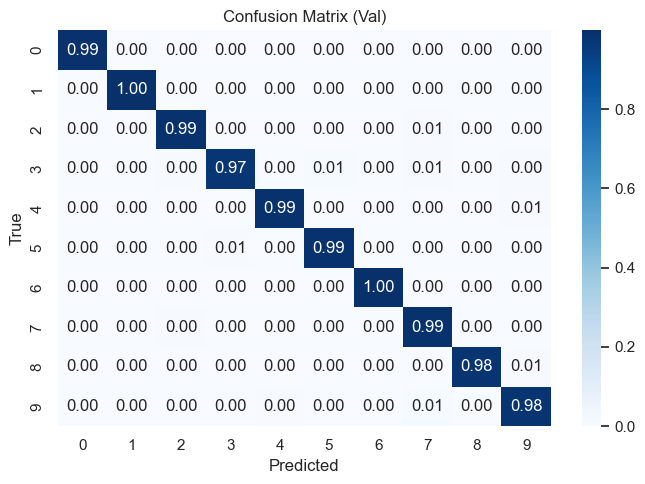

In [71]:
rep_df_aug = report_and_cm(
    y_true_aug, y_pred_aug, title="Confusion Matrix (Val)", normalize="true"
)

The model is great at predicting classes 1 and 6, and worst (98% accurate) at predicting handwritten digits that are a 3. 

Examining the classification report: 

In [72]:
rep_df_aug.head(12)

,precision,recall,f1-score,support
0,0.993954,0.993954,0.993954,827.000000
1,0.995745,0.998933,0.997336,937.000000
2,0.989222,0.988038,0.988630,836.000000
3,0.992974,0.974713,0.983759,870.000000
4,0.988930,0.987715,0.988322,814.000000
5,0.988158,0.989460,0.988808,759.000000
6,0.990396,0.997582,0.993976,827.000000
7,0.975364,0.989773,0.982516,880.000000
8,0.990062,0.981527,0.985776,812.000000
9,0.978571,0.980907,0.979738,838.000000


From these, precision and f1-score are highest for class 1 and lowest for class 9. Recall is still highest for class 1 and lowest for class 9. Looking at some misclassified examples: 

Total misclassified augmented (val): 98


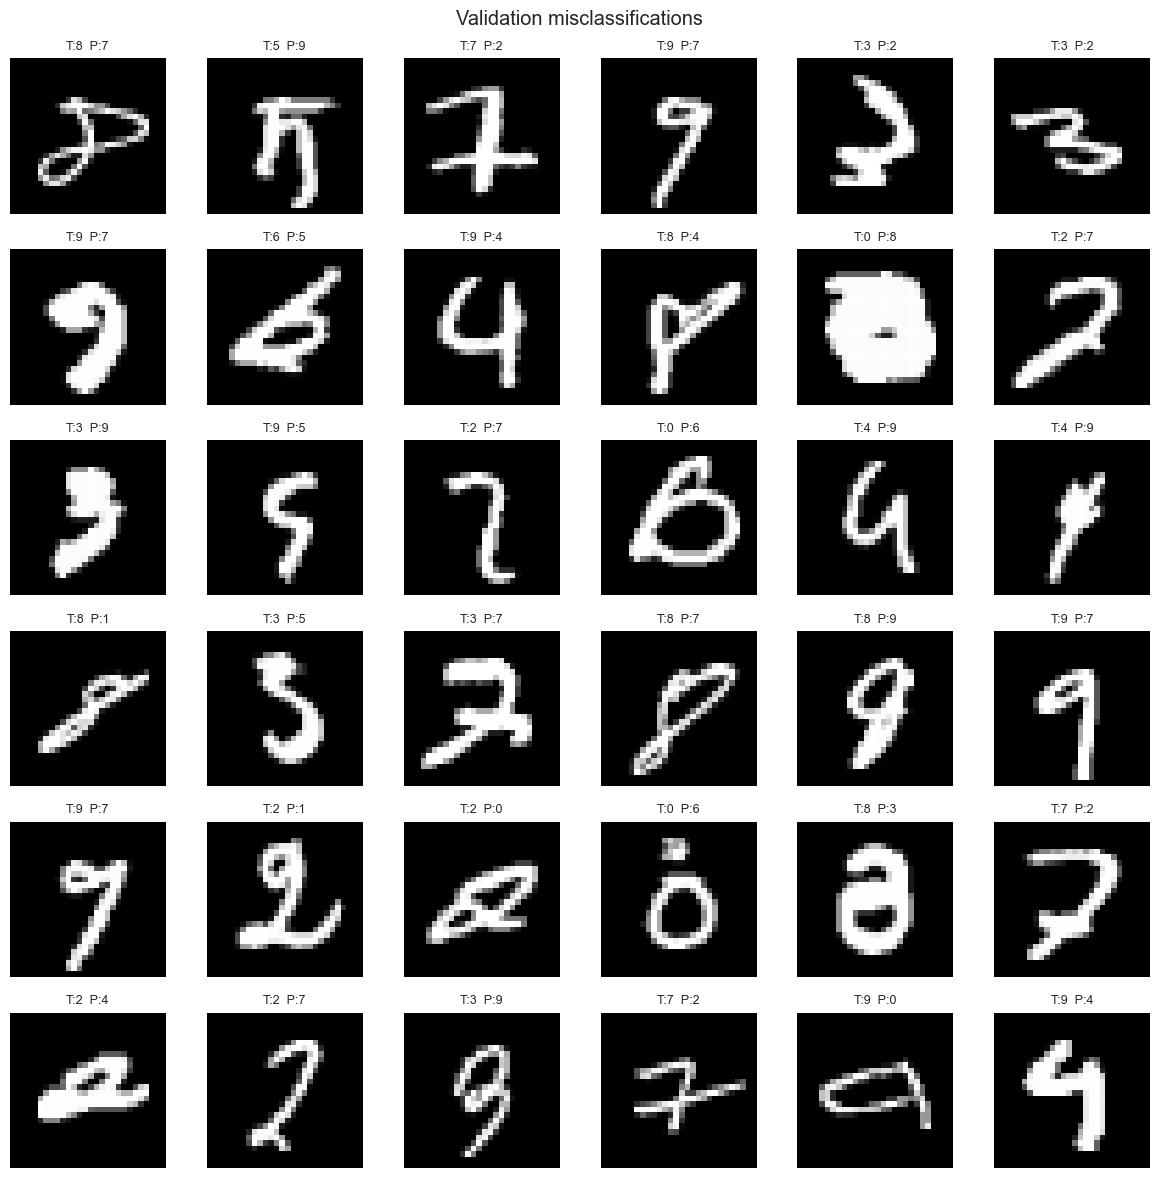

In [73]:
wrong_imgs_aug, wrong_true_aug, wrong_pred_aug, wrong_conf_aug = (
    collect_misclassifications(model_aug, val_loader, device=device)
)
print("Total misclassified augmented (val):", len(wrong_imgs_aug))
show_grid(
    wrong_imgs_aug,
    wrong_true_aug,
    wrong_pred_aug,
    n=36,
    cols=6,
    title="Validation misclassifications",
)

Quite a few of these images are abnormallly shaped.

In [74]:
df_err_aug = pd.DataFrame({"true": y_true_aug, "pred": y_pred_aug})
display(df_err_aug[df_err_aug.true != df_err_aug.pred].value_counts().head(10))

true  pred
9     7       7
3     5       7
4     9       6
2     7       6
3     7       5
8     9       5
7     2       4
9     4       4
3     2       4
      9       4
Name: count, dtype: int64

Now, it is seen that the MLP model tends to mix up 9->7 and 3->5. After parameter optimization, the number of wrongly classified examples has decresed from 150 to 98. 

# Test data evaluation

Now that the best model has been chosen, it can be evaluated on test data: 

In [75]:
test_loader = DataLoader(
    TensorDataset(Xte, yte),
    batch_size=128,
    shuffle=False,
    num_workers=0,  # safer in notebooks
    pin_memory=torch.cuda.is_available(),
)

Test accuracy: 0.9890 | Wrong: 92/8400


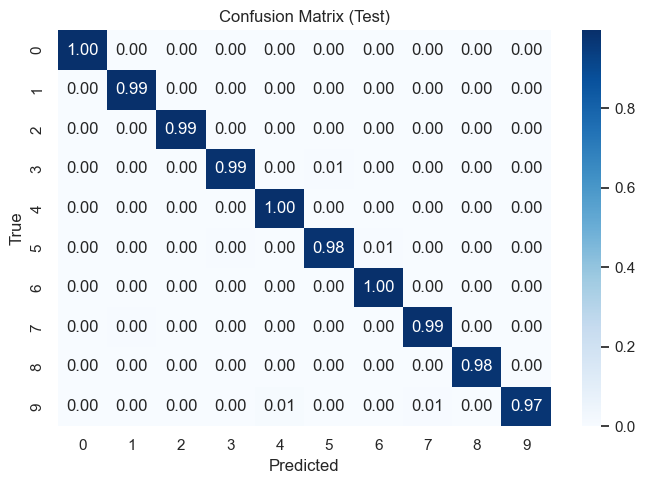

,precision,recall,f1-score,support
0,0.991556,0.995157,0.993353,826.000000
1,0.990436,0.994664,0.992545,937.000000
2,0.991627,0.992814,0.992220,835.000000
3,0.988506,0.988506,0.988506,870.000000
4,0.984242,0.996319,0.990244,815.000000
5,0.982895,0.984190,0.983542,759.000000
6,0.988010,0.995169,0.991576,828.000000
7,0.987542,0.990909,0.989223,880.000000
8,0.991272,0.977860,0.984520,813.000000
9,0.993902,0.973716,0.983705,837.000000


In [76]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else (
        "mps"
        if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
        else "cpu"
    )
)
model_aug = MLP.load_from_checkpoint(final_res_aug["best_ckpt"]).eval()
y_true, y_pred, logits = evaluate_model(model_aug, test_loader, device=device)
acc = float((y_true == y_pred).mean())
n_err = int((y_true != y_pred).sum())
print(f"Test accuracy: {acc:.4f} | Wrong: {n_err}/{len(y_true)}")
rep_df = report_and_cm(
    y_true, y_pred, title="Confusion Matrix (Test)", normalize="true"
)
rep_df.head(12)

This shows that the model generalizes well, with 92 wrong classifications and test accuracy of 0.989. 0, 4, and 6 are the best predicted classes, and 9 is the worst predicted class. 

Looking again at some wrongly classified images: 

Total misclassified (test): 92


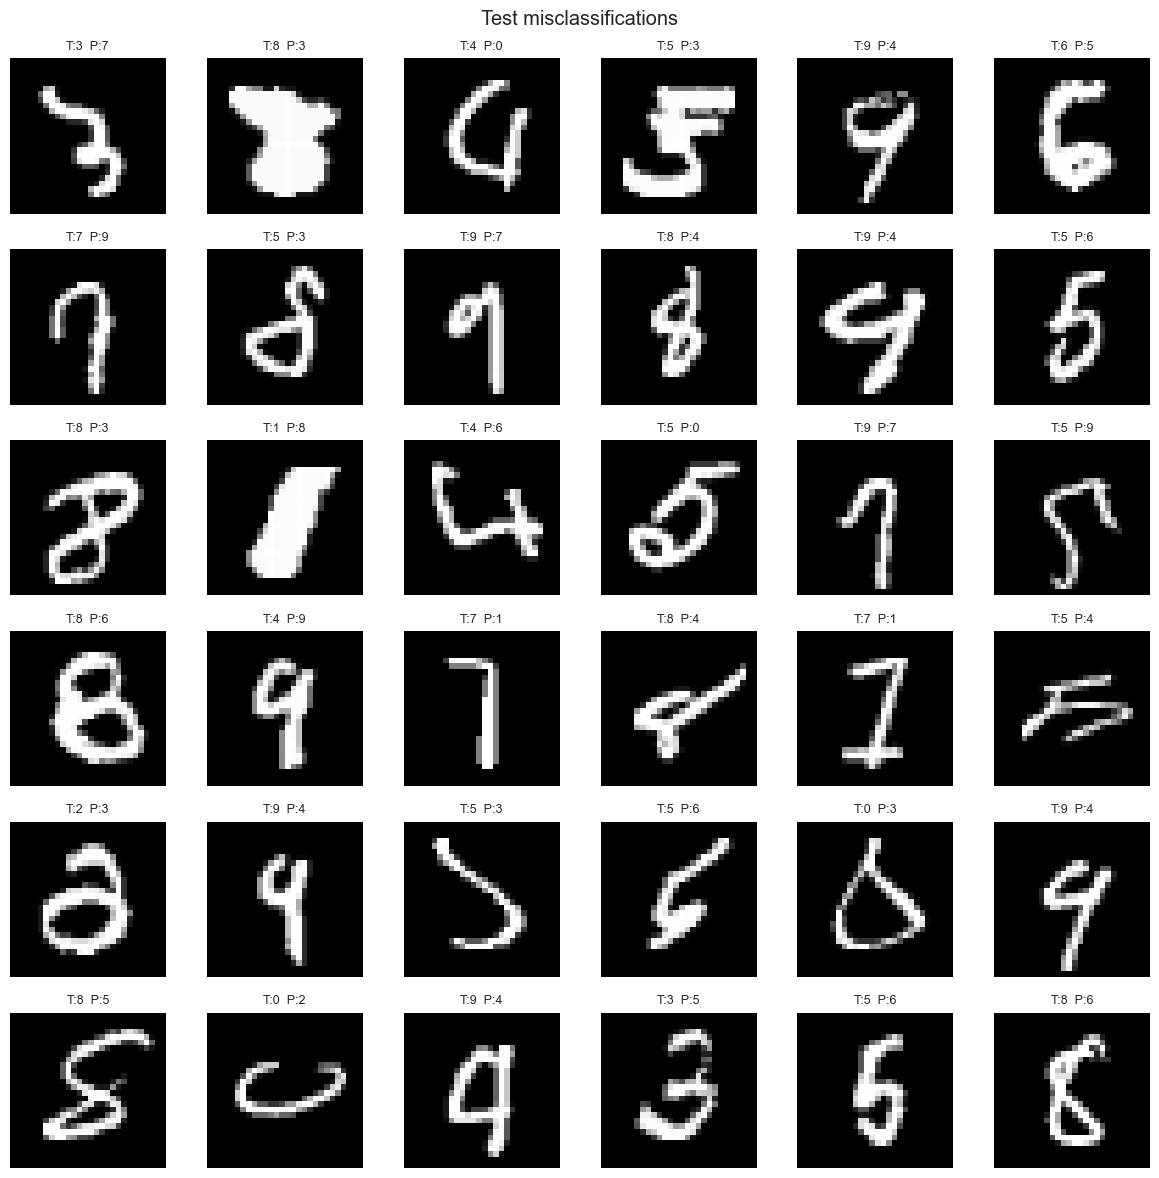

In [77]:
wrong_imgs, wrong_true, wrong_pred, wrong_conf = collect_misclassifications(
    model_aug, test_loader, device=device
)
print("Total misclassified (test):", len(wrong_imgs))
show_grid(
    wrong_imgs, wrong_true, wrong_pred, n=36, cols=6, title="Test misclassifications"
)

Quite a few of these misclassified digits are abnormally shaped again.

# Saving best model

The best model is now saved: 

In [78]:
model_aug = MLP.load_from_checkpoint(final_res_aug["best_ckpt"]).eval()
state_path = "experiments/final_optuna_mlp_aug/best_state_dict.pth"
torch.save(model_aug.state_dict(), state_path)

## Kaggle Test Predictions + Submission

Predictions for Kaggle's test.csv are made to actually test the data: 

First, the test data is loaded and normalized: 

In [79]:
df_test = pd.read_csv("data/test.csv")  # shape (28000, 784)
Xk = torch.tensor(df_test.values, dtype=torch.float32).div_(255.0)  # (N, 784)

In [80]:
dummy_y = torch.zeros(Xk.shape[0], dtype=torch.long)  # not used
kaggle_loader = DataLoader(
    TensorDataset(Xk, dummy_y),
    batch_size=512,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

Next, predictions are inferred with the best model checkpoint: 

In [81]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else (
        "mps"
        if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
        else "cpu"
    )
)
model_aug = MLP.load_from_checkpoint(final_res_aug["best_ckpt"]).to(device).eval()
y_true_dummy, y_pred, _ = evaluate_model(model_aug, kaggle_loader, device=device)
preds = y_pred

Now, the submission.csv file is saved: 

In [ ]:
sub = pd.DataFrame(
    {
        "ImageId": np.arange(1, preds.shape[0] + 1),
        "Label": preds,
    }
)
sub_path = "submission.csv"
sub.to_csv(sub_path, index=False)
print("Saved:", sub_path, "shape:", sub.shape)

Saved: submission.csv shape: (28000, 2)


This results in a Kaggle sugmission score of 0.98832. 

# Conclusion: 

In this project, a reproducible MLP (multilayer perceptron model) has been built using train, validation and test tensors. It was found that performing slight image augmentations (10 degree rotation, 5% image shifting, slanting an image by 5 degrees, zooming the image by 5%). 

Single factor ablation experiments were performed to examine individual parameter contributions to overall validation accuracy. It was found that a learning rate of 0.003 had the most impact on validation accuracy (98.4%, base: 98.2%). Optuna was used to tune these hyperparameters together, and found the following parameter combination to be optimal (validation accuracy of 98.6%): 
- stochastic gradient descent optimizer, 
- learning rate of 0.039, 
- batch size of 64
- GELU activation function,
- Dropout rate of 0, 
- cross entropy loss function
- hidden layer architecture of (512,256,128), 
- focal loss function.

On the test data, the best local validation accuracy was found to be 0.988, which corresponds to a Kaggle score of 0.988. Most common digit confusions were with the number 9, for example: true label 9 predicted as a 7. 

To further improve results, more data augmentation experiments could be tried (ex: perspective shift, light blurring, random erasing), and longer training with higher patience could be done. When examining results, misclassified top-confidence results could also be examined. In addition, a convolutional neural network (CNN) could be used for this problem. More advanced experiment logging could be done, for example using weights and biases tracking. 